# Phase 1-1: 임베딩 기초 품질 테스트

Gemini `embedding-2-preview` 768차원이 **인재 도메인**에서 의미 유사도를 제대로 잡는지 검증한다.

### 검증 항목
1. 임베딩 벡터 기본 스펙 확인 (차원, 정규화)
2. 동일 기술 스택 엔지니어 간 cosine 유사도 (높아야 함)
3. 이종 기술 스택 간 cosine 거리 (낮아야 함)
4. 기술명 유사어/변형 유사도 (Spring ≈ Spring Boot, 도커 ≈ Docker)
5. capability_text vs experience_text 임베딩 특성 차이

In [1]:
from _bootstrap import setup_project_path

setup_project_path()

WindowsPath('C:/Users/mk.jang/Desktop/TLC/08_TSM/retrieval-lab')

In [2]:
import numpy as np
from embedding_retrieval.config import RetrievalConfig
from embedding_retrieval.factory import create_embeddings
from embedding_retrieval.stores.dual_upstash import DualUpstashStore
from embedding_retrieval.scenarios.sample_data import SAMPLE_ENGINEER_PROFILES

config = RetrievalConfig.from_env()
embeddings = create_embeddings(config)

dual_store = DualUpstashStore(
    embeddings=embeddings,
    url=config.vector_store_kwargs["url"],
    token=config.vector_store_kwargs["token"],
)

print(f"Provider: {config.embedding_provider} / {config.embedding_model}")
print("DualUpstashStore 초기화 완료")

Provider: google_genai / gemini-embedding-2-preview
DualUpstashStore 초기화 완료


## 1. 벡터 기본 스펙 확인
- 차원수 768 맞는지
- L2 norm ≈ 1.0 (정규화 여부)

In [3]:
test_texts = [
    "Java / Spring Boot / PostgreSQL",
    "React / TypeScript / Redux",
    "제조업 ERP 시스템 개발 경험이 풍부한 백엔드 개발자",
]

vecs = [np.array(embeddings.embed_query(t)) for t in test_texts]

for i, (t, v) in enumerate(zip(test_texts, vecs)):
    norm = np.linalg.norm(v)
    print(f"[{i}] dim={v.shape[0]}, L2 norm={norm:.6f} | {t[:50]}")

[0] dim=768, L2 norm=1.000000 | Java / Spring Boot / PostgreSQL
[1] dim=768, L2 norm=1.000000 | React / TypeScript / Redux
[2] dim=768, L2 norm=1.000000 | 제조업 ERP 시스템 개발 경험이 풍부한 백엔드 개발자


## 2. 기술명 유사어/변형 유사도

의미적으로 가까운 기술명 쌍의 cosine 유사도가 높게 나오는지 확인.
`exact_skill_score`가 못 잡는 **semantic neighbor**를 dense가 보정할 수 있는지 판단하는 핵심 테스트.

In [4]:
def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

# 유사해야 하는 쌍 (expected: 높은 유사도)
similar_pairs = [
    ("Spring", "Spring Boot"),
    ("Spring", "Spring Security"),
    ("Docker", "도커"),
    ("Kubernetes", "K8s"),
    ("React", "React.js"),
    ("JavaScript", "TypeScript"),
    ("PostgreSQL", "MySQL"),
    ("AWS", "Amazon Web Services"),
    ("HTML", "CSS"),
    ("Figma", "Adobe XD"),
]

# 달라야 하는 쌍 (expected: 낮은 유사도)
dissimilar_pairs = [
    ("Java", "Figma"),
    ("Spring Boot", "Photoshop"),
    ("Kubernetes", "Confluence"),
    ("React", "JMeter"),
    ("Python", "GA4"),
]

print("=== 유사 기술명 쌍 (높아야 함) ===")
print(f"{'A':25s} {'B':25s} {'cosine':>8s}")
print("-" * 62)
for a, b in similar_pairs:
    va = np.array(embeddings.embed_query(a))
    vb = np.array(embeddings.embed_query(b))
    sim = cosine_sim(va, vb)
    print(f"{a:25s} {b:25s} {sim:8.4f}")

print(f"\n=== 이종 기술명 쌍 (낮아야 함) ===")
print(f"{'A':25s} {'B':25s} {'cosine':>8s}")
print("-" * 62)
for a, b in dissimilar_pairs:
    va = np.array(embeddings.embed_query(a))
    vb = np.array(embeddings.embed_query(b))
    sim = cosine_sim(va, vb)
    print(f"{a:25s} {b:25s} {sim:8.4f}")

=== 유사 기술명 쌍 (높아야 함) ===
A                         B                           cosine
--------------------------------------------------------------
Spring                    Spring Boot                 0.7214
Spring                    Spring Security             0.7047
Docker                    도커                          0.7891
Kubernetes                K8s                         0.9482
React                     React.js                    0.9204
JavaScript                TypeScript                  0.7998
PostgreSQL                MySQL                       0.7810
AWS                       Amazon Web Services         0.9250
HTML                      CSS                         0.7969
Figma                     Adobe XD                    0.7037

=== 이종 기술명 쌍 (낮아야 함) ===
A                         B                           cosine
--------------------------------------------------------------
Java                      Figma                       0.4993
Spring Boot               Phot

## 3. 엔지니어 capability_text 간 유사도 매트릭스

9명 엔지니어의 capability_text를 임베딩하고 전체 cosine 유사도 매트릭스를 그린다.
- 같은 직군(백엔드↔백엔드, 프론트↔프론트) 간 유사도가 높아야 함
- 다른 직군(개발자↔디자이너, 개발자↔QA) 간 유사도가 낮아야 함

In [6]:
profiles = SAMPLE_ENGINEER_PROFILES
labels = [f"{p.engineer_id}\n({p.engineer_role[:3]})" for p in profiles]

# Upstash에서 저장된 벡터 fetch — 임베딩 API 재호출 없음
print("capability 벡터 fetch 중...")
cap_vec_map = dual_store.fetch_cap_vectors()   # dict[engineer_id → np.ndarray]
cap_vecs = np.array([cap_vec_map[p.engineer_id] for p in profiles])

print(f"capability 임베딩 shape: {cap_vecs.shape}")

# cosine 유사도 매트릭스
norms = np.linalg.norm(cap_vecs, axis=1, keepdims=True)
cap_normed = cap_vecs / norms
cap_sim_matrix = cap_normed @ cap_normed.T

capability 벡터 fetch 중...
capability 임베딩 shape: (100, 768)


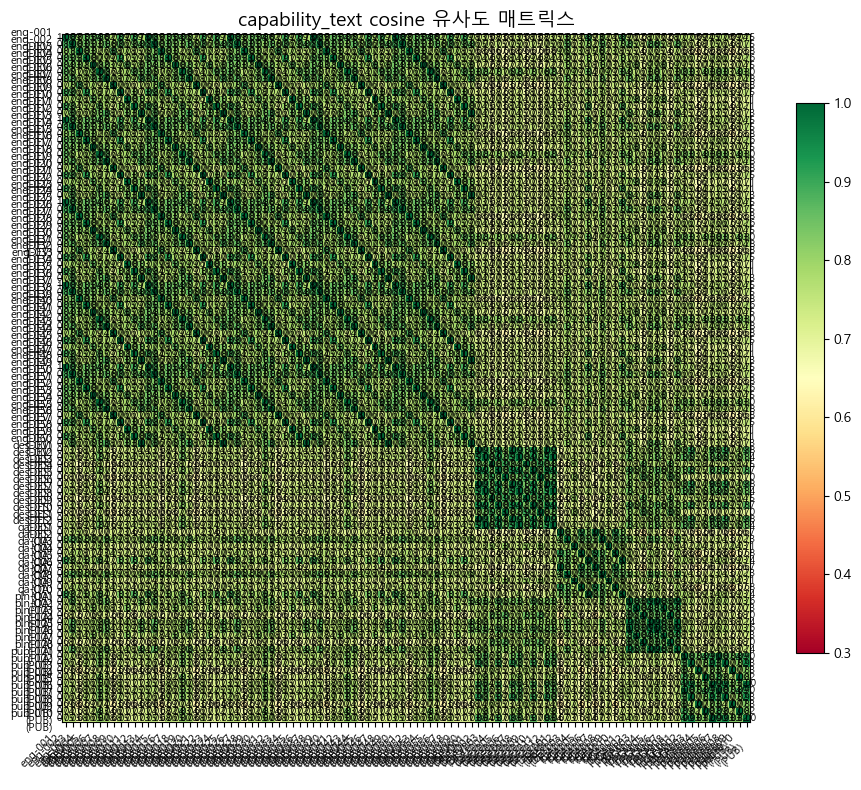

In [7]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cap_sim_matrix, cmap="RdYlGn", vmin=0.3, vmax=1.0)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{cap_sim_matrix[i, j]:.2f}",
                ha="center", va="center", fontsize=7,
                color="white" if cap_sim_matrix[i, j] < 0.5 else "black")

ax.set_title("capability_text cosine 유사도 매트릭스", fontsize=14)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 4. 엔지니어 experience_text 간 유사도 매트릭스

경험/도메인 기반 클러스터링 확인.
- 같은 도메인(제조업↔제조업, 이커머스↔이커머스) 경험자가 가까운지
- capability와 다른 패턴이 나오는지 (capability가 같아도 experience는 다를 수 있음)

In [ ]:
# Upstash에서 저장된 벡터 fetch — 임베딩 API 재호출 없음
print("experience 벡터 fetch 중...")
exp_vec_map = dual_store.fetch_exp_vectors()   # dict[engineer_id → np.ndarray]
exp_vecs = np.array([exp_vec_map[p.engineer_id] for p in profiles])

norms_exp = np.linalg.norm(exp_vecs, axis=1, keepdims=True)
exp_normed = exp_vecs / norms_exp
exp_sim_matrix = exp_normed @ exp_normed.T

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(exp_sim_matrix, cmap="RdYlGn", vmin=0.3, vmax=1.0)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{exp_sim_matrix[i, j]:.2f}",
                ha="center", va="center", fontsize=7,
                color="white" if exp_sim_matrix[i, j] < 0.5 else "black")

ax.set_title("experience_text cosine 유사도 매트릭스", fontsize=14)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 5. capability vs experience 매트릭스 비교 (side-by-side)

두 매트릭스를 나란히 놓고 패턴 차이를 확인.
- capability: 기술 스택이 같으면 높음 (직군 클러스터)
- experience: 도메인/경험이 같으면 높음 (도메인 클러스터)
- 두 매트릭스가 **다른 패턴**을 보여야 듀얼 벡터 분리의 의미가 있음

C:\Users\mk.jang\AppData\Local\Temp\ipykernel_6164\1584657646.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


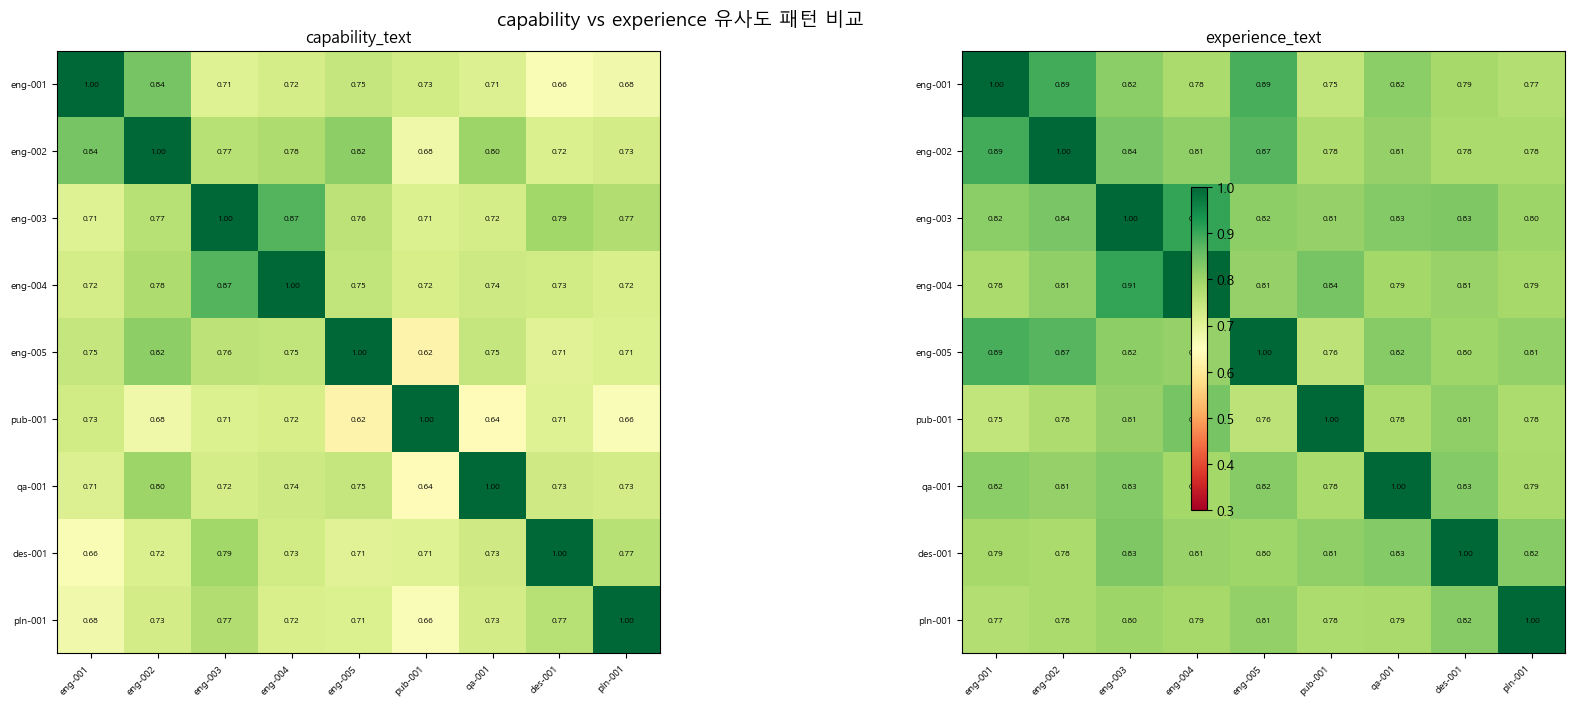


매트릭스 차이 통계 (대각선 제외):
  평균 차이: 0.0773
  최대 차이: 0.1404
  → 차이가 클수록 듀얼 벡터 분리의 의미가 큼


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
short_labels = [f"{p.engineer_id}" for p in profiles]

for ax, matrix, title in [
    (axes[0], cap_sim_matrix, "capability_text"),
    (axes[1], exp_sim_matrix, "experience_text"),
]:
    im = ax.imshow(matrix, cmap="RdYlGn", vmin=0.3, vmax=1.0)
    ax.set_xticks(range(len(short_labels)))
    ax.set_yticks(range(len(short_labels)))
    ax.set_xticklabels(short_labels, fontsize=7, rotation=45, ha="right")
    ax.set_yticklabels(short_labels, fontsize=7)
    for i in range(len(short_labels)):
        for j in range(len(short_labels)):
            ax.text(j, i, f"{matrix[i, j]:.2f}",
                    ha="center", va="center", fontsize=6,
                    color="white" if matrix[i, j] < 0.5 else "black")
    ax.set_title(title, fontsize=12)

fig.colorbar(im, ax=axes, shrink=0.6)
fig.suptitle("capability vs experience 유사도 패턴 비교", fontsize=14)
plt.tight_layout()
plt.show()

# 두 매트릭스 차이 정량화 (대각선 제외)
mask = ~np.eye(len(profiles), dtype=bool)
diff = np.abs(cap_sim_matrix - exp_sim_matrix)
print(f"\n매트릭스 차이 통계 (대각선 제외):")
print(f"  평균 차이: {diff[mask].mean():.4f}")
print(f"  최대 차이: {diff[mask].max():.4f}")
print(f"  → 차이가 클수록 듀얼 벡터 분리의 의미가 큼")

## 6. 쿼리 → 엔지니어 매칭 정확도 테스트

실제 검색 시나리오별로 기대하는 top-3 엔지니어가 나오는지 확인.
- capability 쿼리: 기술 스택으로 검색
- experience 쿼리: 도메인/프로젝트 맥락으로 검색

In [9]:
# 검색 시나리오 정의
# (쿼리, 검색대상, 기대 top-3 engineer_id)
test_scenarios = [
    # capability 검색
    {
        "query": "Java / Spring Boot",
        "target": "capability",
        "expected_top3": ["eng-001", "eng-002"],
        "desc": "Java/Spring 백엔드 기술 검색",
    },
    {
        "query": "React / TypeScript",
        "target": "capability",
        "expected_top3": ["eng-003", "eng-004"],
        "desc": "React 프론트엔드 기술 검색",
    },
    {
        "query": "Figma / Adobe XD / Photoshop",
        "target": "capability",
        "expected_top3": ["des-001"],
        "desc": "디자인 툴 검색",
    },
    {
        "query": "Selenium / JMeter / 테스트 자동화",
        "target": "capability",
        "expected_top3": ["qa-001"],
        "desc": "QA/테스트 도구 검색",
    },
    # experience 검색
    {
        "query": "[프로젝트] 현대차 ERP 시스템 개발: 제조업 ERP 시스템 재구축\n[포지션] 백엔드 개발자\n[기타요건] 현대차 프로젝트 경험 우대",
        "target": "experience",
        "expected_top3": ["eng-001", "eng-002"],
        "desc": "현대차 ERP 제조업 경험 검색",
    },
    {
        "query": "[프로젝트] 금융 앱 UX 개선\n[포지션] UX 디자이너\n[기타요건] 핀테크 경험 우대",
        "target": "experience",
        "expected_top3": ["des-001"],
        "desc": "핀테크 UX 디자이너 경험 검색",
    },
    {
        "query": "[프로젝트] 이커머스 플랫폼 구축\n[포지션] 백엔드 개발자\n[기타요건] 물류/주문 시스템 경험",
        "target": "experience",
        "expected_top3": ["eng-005", "eng-001"],
        "desc": "이커머스/물류 백엔드 경험 검색",
    },
]

print(f"{'시나리오':35s} {'타겟':12s} {'top-1':10s} {'top-2':10s} {'top-3':10s} {'적중'}")
print("-" * 95)

for sc in test_scenarios:
    q_vec = np.array(embeddings.embed_query(sc["query"]))
    
    if sc["target"] == "capability":
        target_vecs = cap_normed
    else:
        target_vecs = exp_normed
    
    q_normed = q_vec / np.linalg.norm(q_vec)
    sims = target_vecs @ q_normed
    ranked_idx = np.argsort(sims)[::-1]
    
    top3_ids = [profiles[i].engineer_id for i in ranked_idx[:3]]
    top3_scores = [sims[i] for i in ranked_idx[:3]]
    
    # 기대 엔지니어가 top-3 안에 있는지
    hit = all(eid in top3_ids for eid in sc["expected_top3"])
    mark = "O" if hit else "X"
    
    t1 = f"{top3_ids[0]}({top3_scores[0]:.3f})"
    t2 = f"{top3_ids[1]}({top3_scores[1]:.3f})"
    t3 = f"{top3_ids[2]}({top3_scores[2]:.3f})"
    
    print(f"{sc['desc']:35s} {sc['target']:12s} {t1:16s} {t2:16s} {t3:16s} {mark}")

시나리오                                타겟           top-1      top-2      top-3      적중
-----------------------------------------------------------------------------------------------
Java/Spring 백엔드 기술 검색               capability   eng-002(0.924)   eng-001(0.817)   eng-005(0.793)   O
React 프론트엔드 기술 검색                   capability   eng-003(0.873)   eng-004(0.847)   eng-002(0.745)   O
디자인 툴 검색                            capability   des-001(0.933)   eng-003(0.776)   pln-001(0.727)   O
QA/테스트 도구 검색                        capability   qa-001(0.851)    eng-001(0.763)   eng-002(0.738)   O
현대차 ERP 제조업 경험 검색                   experience   eng-001(0.837)   eng-002(0.814)   eng-003(0.767)   O
핀테크 UX 디자이너 경험 검색                   experience   des-001(0.814)   qa-001(0.733)    pln-001(0.730)   O
이커머스/물류 백엔드 경험 검색                   experience   eng-005(0.793)   eng-001(0.790)   eng-002(0.782)   O


## 7. 스킬 정규화 후보 — 한글/영문 변형 유사도

`capability_master` 컬렉션의 정규화 임계값(0.85) 설정의 근거 데이터.
- 정확한 변형: 0.85 이상이어야 정규화 가능
- 완전히 다른 스킬: 0.85 미만이어야 오탐 방지

In [14]:
# 정규화 대상 (오타/한글변형 → 마스터명)
normalization_cases = [
    # (입력, 마스터명, 정규화되어야 하는가?)
    ("스프링부트", "Spring Boot", True),
    ("스푸링푸트", "Spring Boot", True),     # 오타
    ("도커", "Docker", True),
    ("쿠버네티스", "Kubernetes", True),
    ("쿠버", "Kubernetes", True),
    ("k8s", "Kubernetes", True),
    ("리액트", "React", True),
    ("타입스크립트", "TypeScript", True),
    ("자바", "Java", True),
    ("파이썬", "Python", True),
    ("포토샵", "Photoshop", True),
    ("피그마", "Figma", True),
    # 다른 스킬 (정규화되면 안 됨)
    ("Java", "Figma", False),
    ("Spring Boot", "React", False),
    ("Docker", "Photoshop", False),
    ("Selenium", "Spring Boot", False),
]

THRESHOLD = 0.75

print(f"{'입력':15s} {'마스터':15s} {'cosine':>8s} {'판정':>6s} {'기대':>6s} {'결과'}")
print("-" * 75)

correct = 0
for term, master, should_match in normalization_cases:
    v_term = np.array(embeddings.embed_query(term))
    v_master = np.array(embeddings.embed_query(master))
    sim = cosine_sim(v_term, v_master)
    
    matched = sim >= THRESHOLD
    expected = should_match
    ok = matched == expected
    correct += ok
    
    print(f"{term:15s} {master:15s} {sim:8.4f} {'매칭' if matched else '미매칭':>6s} "
          f"{'매칭' if expected else '미매칭':>6s} {'O' if ok else 'X'}")

print(f"\n정규화 정확도: {correct}/{len(normalization_cases)} ({correct/len(normalization_cases)*100:.0f}%)")
print(f"임계값: {THRESHOLD}")

입력              마스터               cosine     판정     기대 결과
---------------------------------------------------------------------------
스프링부트           Spring Boot       0.8159     매칭     매칭 O
스푸링푸트           Spring Boot       0.4664    미매칭     매칭 X
도커              Docker            0.7891     매칭     매칭 O
쿠버네티스           Kubernetes        0.8150     매칭     매칭 O
쿠버              Kubernetes        0.5479    미매칭     매칭 X
k8s             Kubernetes        0.8713     매칭     매칭 O
리액트             React             0.8049     매칭     매칭 O
타입스크립트          TypeScript        0.8569     매칭     매칭 O
자바              Java              0.8249     매칭     매칭 O
파이썬             Python            0.7974     매칭     매칭 O
포토샵             Photoshop         0.8254     매칭     매칭 O
피그마             Figma             0.7959     매칭     매칭 O
Java            Figma             0.4993    미매칭    미매칭 O
Spring Boot     React             0.6364    미매칭    미매칭 O
Docker          Photoshop         0.5874    미매칭    미매칭 O
Selenium   